# Time Series Forecasting with TorchGeo: Air Quality Tutorial

In this tutorial, we demonstrate how to train a multivariate time series forecasting model using TorchGeo. Univariate ($\mathbb{R}^{T}$) and multivariate ($\mathbb{R}^{T \times C}$) regression are the foundation of time series analysis, with several important applications in Earth science. A variety of autoregressive models can be used to tackle 1D time series, including convolution-based models like TempCNN and attention-based models like the Lightweight Temporal Attention Encoder (L-TAE).

We train an autoregressive model on the UCI Air Quality dataset, then use it to forecast future concentrations of pollutants such as Carbon Monoxide ($\mathrm{CO}$), Benzene ($\mathrm{C_6H_6}$), Total Nitrogen Oxides ($\mathrm{NO_x}$) or Nitrogen Dioxide ($\mathrm{NO_2}$).

This tutorial introduces three TorchGeo components designed for time series:

| Component | Description |
|-----------|-------------|
| `AirQuality` / `AirQualityDataModule` | Hourly air-quality sensor data (UCI, Italian roadside station, 2004–2005) with chronological splitting and per-feature normalisation |
| `LTAE` | Lightweight Temporal Attention Encoder — encodes a variable-length sequence `(B, T, C)` into a fixed embedding `(B, d)` |
| `TemporalRegressionTask` | Lightning module that wires the encoder to a regression head, loss function, and evaluation metrics |

**What we are predicting:** given the last 3 days of readings across the sensor channels `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)`, forecast the next 12 hours for all channels simultaneously.

## Imports

First, we import TorchGeo and the supporting libraries. `L.seed_everything` fixes the random seed for weight initialisation, data shuffling, and dropout, ensuring that results are fully reproducible across runs.

In [ ]:
import lightning as L
from torchgeo.datasets import AirQuality
from torchgeo.datamodules import AirQualityDataModule
from torchgeo.trainers import TemporalRegressionTask
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
L.seed_everything(0, workers=True)

Seed set to 0


0

## The UCI Air Quality dataset

The dataset contains 13 sensor channels measured every hour for approximately 13 months at a roadside station in Italy (March 2004 – February 2005). Channels include ground-truth reference analyser concentrations of CO, non-methane hydrocarbons (NMHC), benzene, total nitrogen oxides, and nitrogen dioxide, alongside metal-oxide sensor responses that act as indirect proxies. We exclude the `NMHC(GT)` channel, which is predominantly missing. Missing values encoded as `-200` in the raw data are handled automatically by `AirQuality` via linear interpolation.

Each sample in the dataset consists of:
- **`input`**: a window of `NUM_PAST_STEPS` hourly readings across all channels
- **`target`**: the subsequent `NUM_FUTURE_STEPS` hourly readings for all channels

We set `NUM_PAST_STEPS = 72` (3 days of context) and `NUM_FUTURE_STEPS = 12` (a 12-hour forecast horizon). These values reflect a practical short-range air quality forecasting scenario, where recent diurnal cycles provide context while the forecast horizon covers a half-day period relevant for public health advisories.

In [43]:
NUM_PAST_STEPS   = 72
NUM_FUTURE_STEPS = 12

We download the dataset, select the channels `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)` as `FEATURES` and inspect its structure and summary statistics. The varying scales across features suggest the need for normalization, which is handled by the `AirQualityDataModule`, which is explained subsequently.

In [ ]:
FEATURES = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
NUM_FEATURES = len(FEATURES)

DATASET_CONFIG = dict(
    root='data',
    download=True,
    num_input_steps=NUM_PAST_STEPS,
    num_target_steps=NUM_FUTURE_STEPS,
    features=FEATURES,
)

dataset = AirQuality(**DATASET_CONFIG)
dataset.data.describe().T[['count', 'mean', 'std', 'min', 'max']]


,count,mean,std,min,max
CO(GT),9357.0,2.130603,1.431736,0.1,11.9
C6H6(GT),9357.0,10.179155,7.503812,0.1,63.7
NOx(GT),9357.0,241.922197,204.315075,2.0,1479.0
NO2(GT),9357.0,109.632094,46.462311,2.0,340.0


The dataset includes a built-in plotting function that allows us to visualize input–target sequences directly. We can inspect individual samples, each containing past observations and the corresponding future values that the model is expected to predict. We visualize the CO(GT) channel for a single sample:

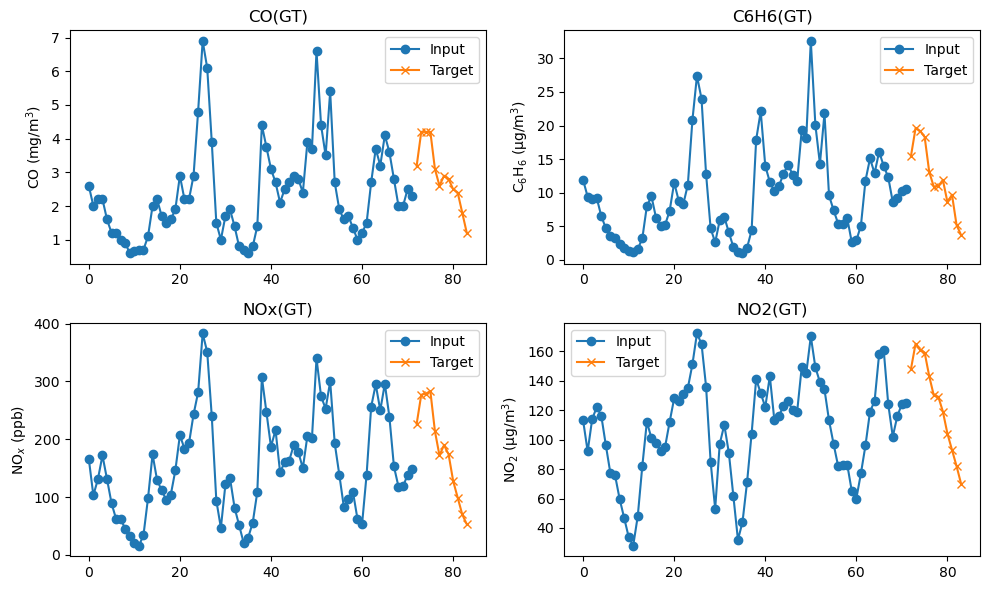

In [45]:
sample = dataset[0]
_ = dataset.plot(sample)

## Lightning Modules

TorchGeo uses PyTorch Lightning to organise training code and set up data loaders. `AirQualityDataModule` handles loading, normalisation, and splitting in one place:

1. Downloads the data if not already present
2. Splits the dataset **chronologically** into train (70%), validation (15%), and test (15%) subsets
3. Applies per-feature z-score normalisation, with mean and standard deviation computed **from the training set only**

**Why chronological splitting?** In time series, a random split would cause *temporal leakage*: the model would implicitly see future observations during training (embedded in shuffled batches), artificially inflating evaluation metrics. By splitting in strict time order, earliest data for training, most recent for testing, we obtain an honest estimate of how well the model generalises to unseen future conditions, which is the quantity that matters in operational forecasting.

**Why fit normalisation only on the training set?** Computing statistics on the full dataset would leak distributional information about the validation and test periods into preprocessing, a subtle but consequential form of data leakage. Fitting z-score parameters on training data only ensures that the held-out sets are normalised using only information that would be available in a real deployment.

In [46]:
dm = AirQualityDataModule(
    **DATASET_CONFIG,
    batch_size=128,
    num_workers=0,
    val_split_pct=0.15,
    test_split_pct=0.15,
)

For training a temporal regression model, we use `TemporalRegressionTask` from `torchgeo.trainers`, which handles:

1. Encoding the input sequence through the L-TAE encoder
2. Projecting the fixed-size embedding to the output dimension via a linear regression head
3. Computing MSE loss in normalised space during training
4. Reporting RMSE and MAE in physical units (de-normalised before metric computation) for interpretable evaluation

We use the **Lightweight Temporal Attention Encoder** (L-TAE; Garnot & Landrieu, 2020) as the backbone. Unlike recurrent architectures such as LSTMs, L-TAE does not process the sequence step-by-step; instead, it computes a single learned query vector that attends to *all* timesteps simultaneously via multi-head self-attention, yielding a fixed-size embedding regardless of sequence length. This design avoids the vanishing-gradient issues of RNNs over long sequences and produces an explicit, inspectable attention weight for every timestep, making it possible to examine which hours of the context window the model found most informative.

The output dimension `NUM_OUTPUTS = NUM_FUTURE_STEPS × NUM_FEATURES` reflects that we predict all selected channels at every future timestep jointly, as a single flat vector that is reshaped after inference.

Key configuration choices:

| Parameter | Value | Role |
|-----------|-------|------|
| `n_head` | 4 | Number of attention heads; each head can specialise on a different temporal pattern (e.g. diurnal vs. multi-day trends) |
| `d_k` | 8 | Dimension of the query and key projections per head; controls the expressiveness of each head's attention scoring |
| `d_model` | 64 | Dimension of the encoder output embedding passed to the regression head |
| `n_neurons` | (64, 32) | Hidden layer widths of the two-layer MLP regression head |
| `dropout` | 0.1 | Dropout probability applied inside the attention mechanism for regularisation |
| `loss` | `'mse'` | Mean squared error, computed in normalised space |
| `lr` | 3e-4 | Adam learning rate |

In [47]:
task = TemporalRegressionTask(
    model='ltae', in_channels=NUM_FEATURES,
    num_outputs=NUM_FUTURE_STEPS * NUM_FEATURES,
    loss='mse', lr=3e-4, patience=5,
    n_head=4, d_k=8, d_model=64, n_neurons=(64, 32),
    dropout=0.1, len_max_seq=NUM_PAST_STEPS, T=1000,
)

## Training

We train the model using Lightning's `Trainer`, configured with three components:

- **`TensorBoardLogger`**: records training and validation loss at every epoch to a local `tb_logs/` directory. TensorBoard reads these logs and renders interactive plots.
- **`ModelCheckpoint`**: saves the model weights corresponding to the lowest validation loss observed during training.
- **`EarlyStopping`**: monitors validation loss and halts training automatically if it fails to improve for consecutive epochs.

In [48]:
trainer = Trainer(
    max_epochs=100,
    logger=TensorBoardLogger("tb_logs", name="air_quality"),
    callbacks=[
        ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1),
        EarlyStopping(monitor='val_loss', patience=25, mode='min'),
    ],
)

trainer.fit(task, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Sequential       | 30.0 K | train
1 | criterion     | MSELoss          | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
30.0 K    Trainable params
0         Non-trainable params
30.0 K    Total params
0.120     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Epoch 33: 100%|██████████| 50/50 [00:02<00:00, 22.54it/s, v_num=18]        


## Evaluation

`trainer.test()` automatically restores the best checkpoint saved by `ModelCheckpoint` and runs a single forward pass over the held-out test set.

In [49]:
trainer.test(task, datamodule=dm)

Testing DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 54.22it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MAE          │     47.36052322387695     │
│         test_MSE          │      8635.498046875       │
│         test_RMSE         │     92.92738342285156     │
│         test_loss         │    1.0140646696090698     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.0140646696090698,
  'test_MAE': 47.36052322387695,
  'test_MSE': 8635.498046875,
  'test_RMSE': 92.92738342285156}]

**Interpreting the normalised loss.** The `test_loss` is the MSE computed in the z-score-normalised space shared by all channels. A value below 1.0 indicates that the model's average squared error per normalised channel is smaller than the training-set variance of that channel, meaning that the model would perform better than predicting the channel mean for every future timestep.

**Interpreting the physical-unit metrics.** The MAE and RMSE are computed after inverting the z-score normalisation, so they are reflecting the physical sensor readings. Because the dataset contains both low-range analyte concentrations and high-range metal-oxide sensor signals, the aggregate RMSE is heavily influenced by the high-magnitude channels. These aggregate figures are best understood as a holistic benchmark for comparing model variants, rather than as per-pollutant accuracy estimates. For operational interpretation, per-channel metrics should be computed separately after de-normalising each feature independently.

## Inspecting Training Dynamics with TensorBoard

The cell below launches TensorBoard directly inside the notebook. TensorBoard reads the event files written to `tb_logs/` during training and provides an interactive dashboard:

In [ ]:
%load_ext tensorboard
%tensorboard --logdir tb_logs

## To Go Further

- **Adjust the forecasting horizon**: decrease `NUM_PAST_STEPS` and `NUM_FUTURE_STEPS` for short-term nowcasting (e.g. 24 h context → 1 h forecast), or increase them for long-context environmental modelling over multiple days.
- **Compare encoder architectures**: replace L-TAE with a convolution-based encoder such as `TempCNN` to contrast the inductive biases of attention-based versus convolutional temporal modelling on the same task.
- **Apply to other sensor datasets**: the `TemporalRegressionTask` workflow is dataset-agnostic; swap in any custom dataset that returns `input` and `target` tensors to benchmark the same pipeline on different environmental monitoring problems.
- **Incorporate temporal positional encodings**: extend the model with timestamp-derived features to help it learn diurnal and weekly pollution cycles that are not recoverable from sensor values alone.